# From fitting a trajectory to fitting a transition function - Non Linear 2D

In [1]:
%loadlibs
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
from scipy.integrate import solve_ivp
from torch.func import jacrev
from pcgrad import PCGrad
import pandas as pd
torch.set_default_device('mps')

Loaded libraries:
	- numpy (np)
	- matplotlib.pyplot (plt)
	- torch
	- torch.nn (nn)
	- torch.optim (optim)
	- tqdm


Training a PINN for learning a dynamical system 
$$\dot{x}(t) = f(x(t))$$
consists in learning a transition function
$$x(t) = \phi(t, t_0, x(t_0)),$$
where $x(t)$ is a solution of the first equation. To do so, classically, in the literature, one trains a MLP $f^{\text{NN}}(x)$ such that
$$\dot{f^{\text{NN}}} = f,$$
or
$$\frac{\partial f^{\text{NN}}}{\partial t} = f.$$
However, additional constraint can usually be inferred from the initial system:
- Consistency: $\phi(t, t, x(t)) = x$,
- Composition: $\phi(t_2, t_0, x(t_0)) = \phi(t_2, t_1, \phi(t_1, t_0, x(t_0)))$,
- Stationarity: $\phi(t, t_0, x(t_0)) = \phi(t+\delta t, t_0+\delta t, x(t_0))$.

In this work, we show:
1. The learned trajectories are qualitatively and quantitatively correct before adding the new constraints
2. The learned phase portrait is not correct
3. Adding new constraints allows for correcting the phase portrait

We work with a non-linear, stationary system
\begin{equation}
    \begin{cases}
        \dot{x}_1 &= x_2\\
        \dot{x}_2 &= \mu (1-x_1^2)x_2 - x1
    \end{cases}
\end{equation}
with $\mu$ a constant

In [2]:
mu = 1.
    
def get_sol(interval, c_i):
    def xdot(t, x):
        return [x[1], mu*(1-x[0]**2)*x[1] - x[0]]
    sol = solve_ivp(xdot, interval, c_i, t_eval=np.linspace(interval[0], interval[1], 1000))
    return np.concatenate([sol.t.reshape((1, sol.t.shape[0])), sol.y[0:1], sol.y[1:2]])
    
def true_trajectory(interval: list[int], c_i: list[int], ax=None, color='black') -> None:
    sol = get_sol(interval, c_i)
    if ax:
        ax.plot(sol[1, :], sol[2, :], label="Trajectoire ("+r"$x(0)$"+f" = {c_i})", linestyle='dashed', color=color)
        ax.set_xlabel(r"$x_1$")
        ax.set_ylabel(r"$x_2$")
    else:
        plt.plot(sol[1, :], sol[2, :], label="Trajectoire ("+r"$x(0)$"+f" = {c_i})", linestyle='dashed', color=color)
        plt.xlabel(r"$x_1$")
        plt.ylabel(r"$x_2$")

def true_phase_portrait(ax=None):
    lim = 3.5
    x1, x2 = np.meshgrid(np.arange(-lim, lim, 0.4), np.arange(-lim, lim, 0.2))
    x1_values = x2
    x2_values = mu * (1-x1**2)*x2 - x1

    norms = np.sqrt(x1_values**2 + x2_values**2)
    x1_normalized = x1_values / norms
    x2_normalized = x2_values / norms

    vector_scale = 25
    if not ax:
        plt.quiver(x1, x2, x1_normalized, x2_normalized, scale=vector_scale)
        plt.xlim([-lim, lim])
        plt.ylim([-lim, lim])
        plt.grid()
    else:
        ax.quiver(x1, x2, x1_normalized, x2_normalized, scale=vector_scale)
        ax.set_xlim([-lim, lim])
        ax.set_ylim([-lim, lim])
        ax.set_title("Reference")

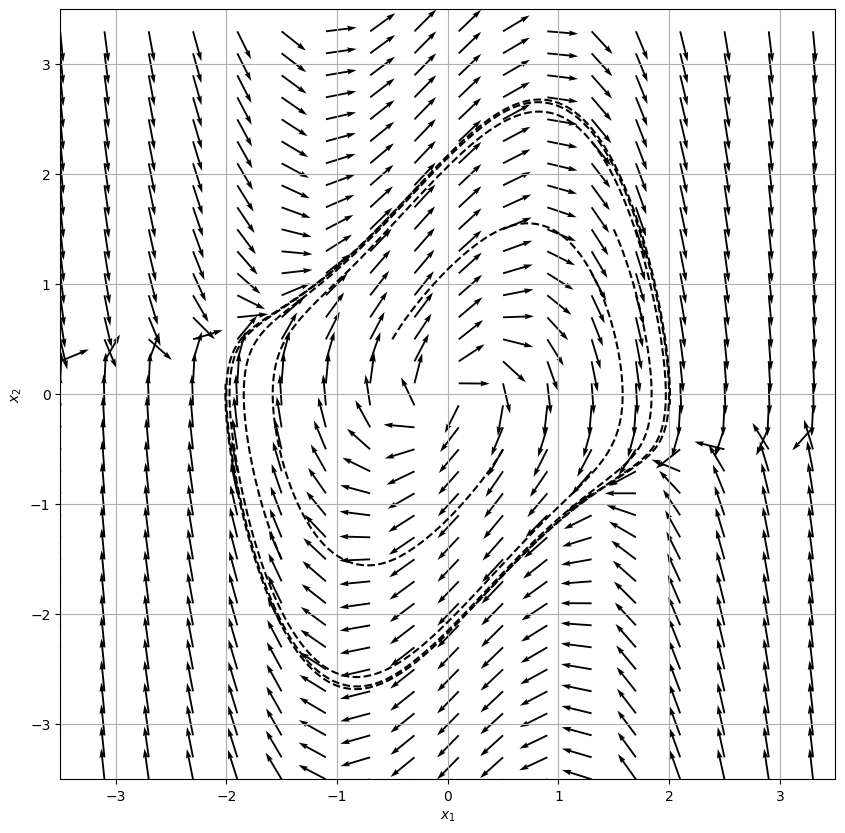

In [44]:
n_points = 5192*2
n_epochs = 2048*2

T_MAX = 7.
c_is = [[-1.5,-1.5], [-0.5,0.5], [0.5,-0.5], [1.5,1.5]]

plt.figure(figsize=(10, 10))
for c_i in c_is:
    true_trajectory((0, T_MAX), c_i)

true_phase_portrait()

In [55]:
class XSinLayer(nn.Module):
    def __init__(self):
        super().__init__()
    def forward(self, x):
        return torch.sin(x) * x
        
class TransitionPINN(nn.Module):
    def __init__(self, layer_size=256):
        super().__init__()
        self.l1 = nn.Linear(4, layer_size)
        self.l2 = nn.Linear(layer_size, layer_size)
        self.l3 = nn.Linear(layer_size, layer_size)
        self.l4 = nn.Linear(layer_size, layer_size)
        self.l5 = nn.Linear(layer_size, layer_size)
        self.l6 = nn.Linear(layer_size, 2)
        self.activation = XSinLayer()

    def forward(self, t, t0, x1_0, x2_0):
        inputs = torch.concatenate([t, t0, x1_0, x2_0], axis=-1)
        x = self.activation(self.l1(inputs))
        x = self.activation(self.l2(x))
        x = self.activation(self.l3(x))
        x = self.activation(self.l4(x))
        x = self.activation(self.l5(x))
        return (t-t0) * self.l6(x) + torch.concatenate([x1_0, x2_0], axis=-1)

def loss_physics(model, t, t0, x1_0, x2_0):
    x1x2 = model(t, t0, x1_0, x2_0)
    x1, x2 = x1x2[:, 0:1], x1x2[:, 1:2]
    dx1_dt = torch.autograd.grad(x1, t, grad_outputs=torch.ones_like(t), create_graph=True)[0]
    dx2_dt = torch.autograd.grad(x2, t, grad_outputs=torch.ones_like(t), create_graph=True)[0]
    loss_x1 = ((dx1_dt - x2)**2).mean()
    loss_x2 = ((dx2_dt - (mu * (1-x1**2)*x2 - x1))**2).mean()
    return loss_x1 + loss_x2

In [56]:
def train_model(seed: int):
    torch.random.manual_seed(seed)
    model_1 = TransitionPINN()
    optimizer = optim.Adam(model_1.parameters(), lr=1e-3)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=200, min_lr=1e-5)
    
    for _ in (pbar:=tqdm(range(n_epochs))):
        optimizer.zero_grad()
        t0 = torch.rand((n_points, 1), requires_grad=True) * T_MAX
        t = t0 + torch.rand((n_points, 1), requires_grad=True) * (T_MAX-t0)
        x1_0 = (torch.rand((n_points, 1), requires_grad=True)-0.5) * 6.
        x2_0 = (torch.rand((n_points, 1), requires_grad=True)-0.5) * 6.
        loss = loss_physics(model_1, t, t0, x1_0, x2_0)
        loss.backward()
        optimizer.step()
        scheduler.step(loss.item())
        pbar.set_description(f"Loss Physics: {loss.item():.4e}")
    return model_1

In [57]:
model_1 = train_model(0)

  0%|          | 0/4096 [00:00<?, ?it/s]

In [58]:
def model_trajectory(model, interval: list[int], c_i: list[int], ax=None, color='black') -> None:
    t_eval = torch.linspace(interval[0], interval[1], 250).unsqueeze(-1)
    x1x2 = model(t_eval, torch.zeros_like(t_eval), torch.ones_like(t_eval)*c_i[0], torch.ones_like(t_eval)*c_i[1]).detach().cpu().squeeze().numpy()
    x1, x2 = x1x2[:, 0], x1x2[:, 1]
    if ax:
        ax.plot(x1, x2, label="Trajectoire ("+r"$x(0)$"+f" = {c_i})", color=color)
        ax.set_xlabel(r"$x_1$")
        ax.set_ylabel(r"$x_2$")
    else:
        plt.plot(x1, x2, label="Trajectoire ("+r"$x(0)$"+f" = {c_i})", color=color)
        plt.xlabel(r"$x_1$")
        plt.ylabel(r"$x_2$")

def model_phase_portrait(model, ax, t=1., opacity=1.):
    x1_0, x2_0 = torch.meshgrid(torch.arange(-1.5, 1.6, 0.2), torch.arange(-1.5, 1.6, 0.2))
    x1_0 = x1_0.flatten().unsqueeze(-1)
    x2_0 = x2_0.flatten().unsqueeze(-1)
    t = torch.ones_like(x1_0, requires_grad=True)*t
    x1x2 = model(t, t.detach(), x1_0, x2_0)
    x1, x2 = x1x2[:, 0:1], x1x2[:, 1:2]
    x1_values = torch.autograd.grad(x1, t, grad_outputs=torch.ones_like(t), create_graph=True)[0].cpu().detach().squeeze().numpy()
    x2_values = torch.autograd.grad(x2, t, grad_outputs=torch.ones_like(t), create_graph=True)[0].cpu().detach().squeeze().numpy()

    norms = np.sqrt(x1_values**2 + x2_values**2)
    x1_normalized = x1_values / norms
    x2_normalized = x2_values / norms

    vector_scale = 25
    ax.quiver(x1_0.cpu().detach().squeeze(), x2_0.cpu().detach().squeeze(), x1_normalized, x2_normalized, scale=vector_scale, alpha=opacity)
    ax.set_xlim([-1.5, 1.5])
    ax.set_ylim([-1.5, 1.5])
    ax.set_title(f"t: {t[0].item()}")

In [59]:
def display_results(model):
    c_i1, c_i2 = np.meshgrid(np.arange(-1, 1.5, 0.5), np.arange(-1, 1.5, 0.5))
    c_is = (np.array(list(zip(c_i1.flatten(), c_i2.flatten()))))
    fig, ax = plt.subplots(1, 3, figsize=(30, 10))
    colors = plt.cm.magma(np.linspace(0, 1, len(c_is)))

    for c_i, color in zip(c_is, colors):
        model_trajectory(model, (0, T_MAX), c_i, ax=ax[0], color=color)
        true_trajectory((0, T_MAX), c_i, ax=ax[0], color=color)
    ax[0].set_xlim(-1.5, 1.5)
    ax[0].set_ylim(-1.5, 1.5)
    ax[0].grid()
    for t in np.arange(0, T_MAX, .5):
        model_phase_portrait(model, ax[1], t, opacity=t/T_MAX)
    ax[1].set_title("Phase portrait of the model through time")
    ax[1].legend([f"t={t}" for t in np.arange(0, T_MAX, .5)])
    true_phase_portrait(ax[2])
    model_phase_portrait(model, ax[2], 0, opacity=0.5)
    ax[2].legend(["Reference", "Model at t=0"])
    ax[2].set_title("Reference and model")

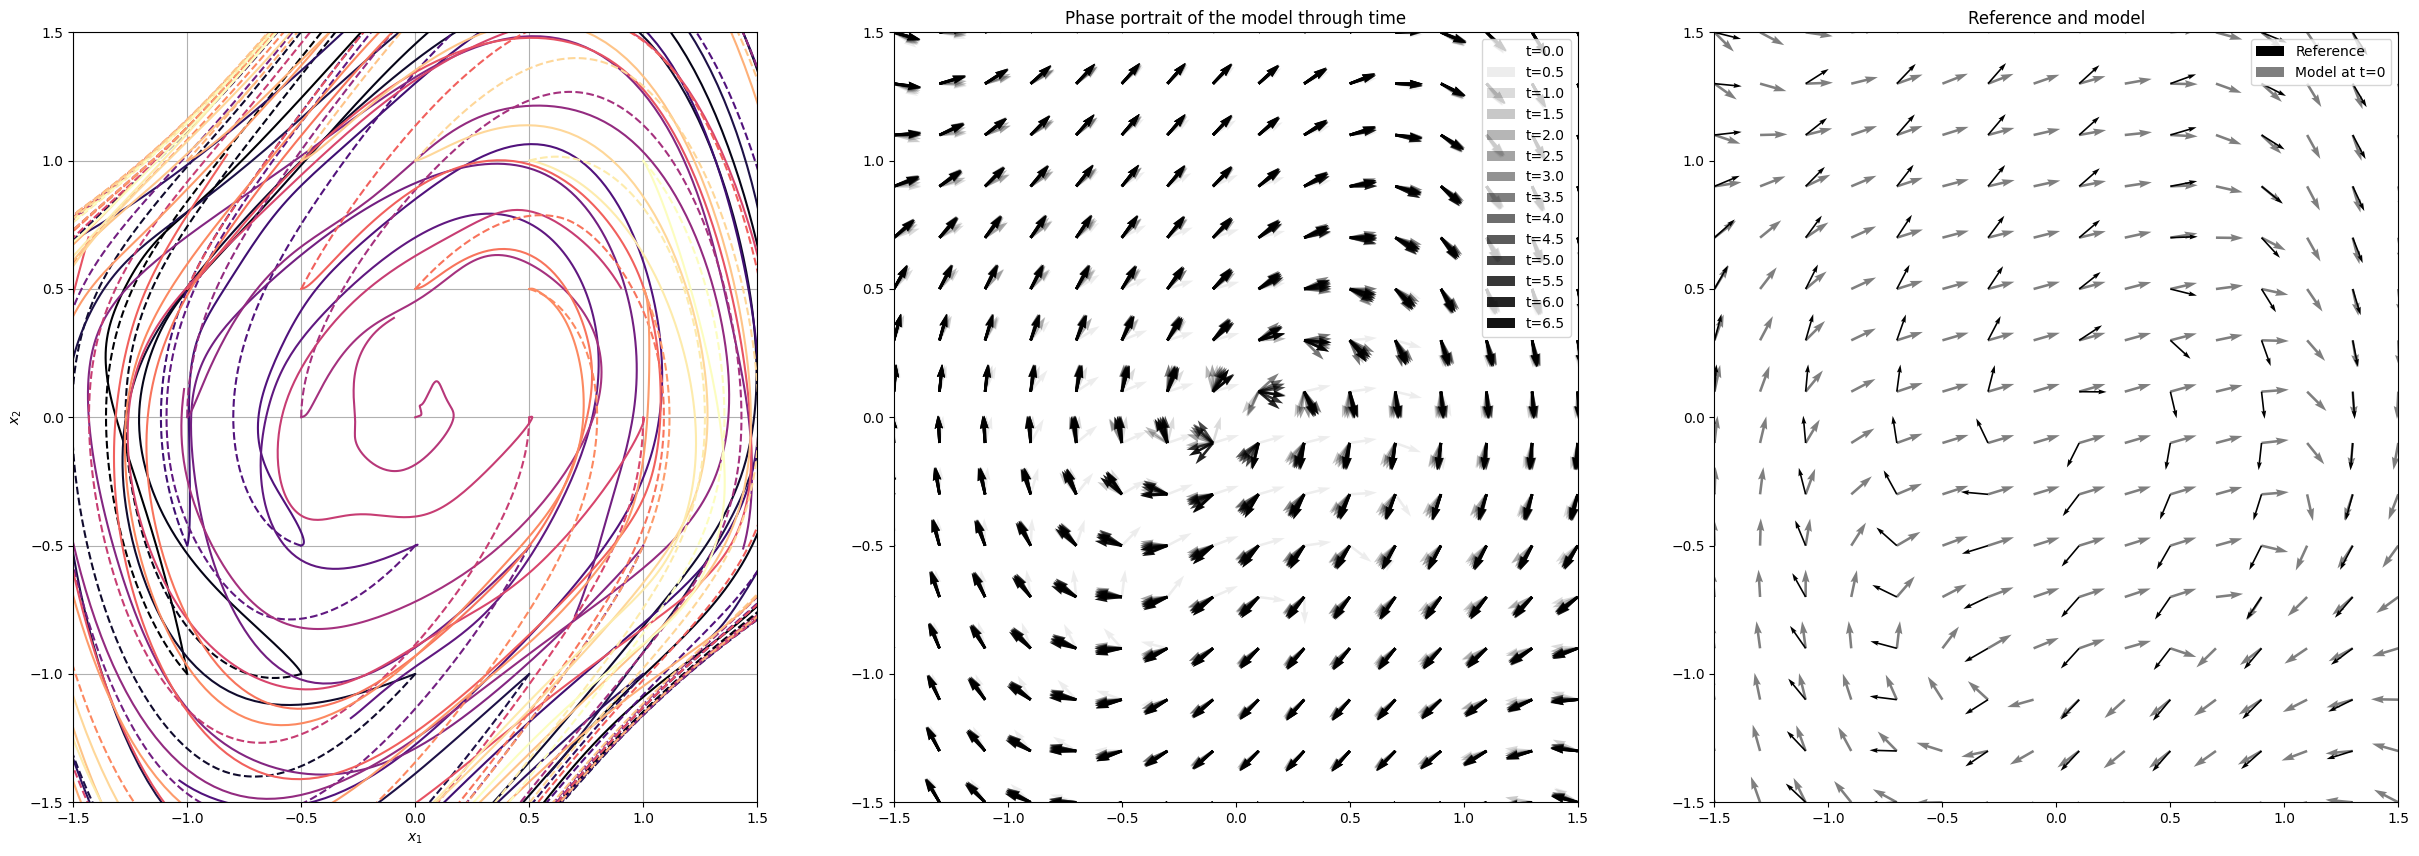

In [60]:
display_results(model_1)
plt.show()

- Consistency: $\phi(t, t, x(t)) = x$,
- Composition: $\phi(t_2, t_0, x(t_0)) = \phi(t_2, t_1, \phi(t_1, t_0, x(t_0)))$,
- Stationarity: $\phi(t, t_0, x(t_0)) = \phi(t+\delta t, t_0+\delta t, x(t_0))$.

In [67]:
class TransitionPINN2(nn.Module):
    def __init__(self, layer_size=256):
        super().__init__()
        self.l1 = nn.Linear(4, layer_size)
        self.l2 = nn.Linear(layer_size, layer_size)
        self.l3 = nn.Linear(layer_size, layer_size)
        self.l4 = nn.Linear(layer_size, layer_size)
        self.l5 = nn.Linear(layer_size, layer_size)
        self.l6 = nn.Linear(layer_size, 2)
        self.activation = XSinLayer()

    def forward(self, t, t0, x1_0, x2_0):
        tau = t - t0
        inputs = torch.concatenate([tau, tau**1.2, x1_0, x2_0], axis=-1)
        x = self.activation(self.l1(inputs))
        x = self.activation(self.l2(x))
        x = self.activation(self.l3(x))
        x = self.activation(self.l4(x))
        x = self.activation(self.l5(x))
        return tau * self.l6(x) + torch.concatenate([x1_0, x2_0], axis=-1)

In [68]:
def consistency_loss(model, t0, x1_0, x2_0):
    x1x2 = model(t0, t0, x1_0, x2_0)
    return ((x1x2-torch.concatenate([x1_0, x2_0], axis=-1))**2).mean()

def composition_loss(model, t, t0, t1, x1_0, x2_0):
    x1 = model(t, t0, x1_0, x2_0)
    x1x2_1 = model(t1, t0, x1_0, x2_0)
    x1_1, x2_1 = x1x2_1[:, 0:1].detach(), x1x2_1[:, 1:2].detach()
    x2 = model(t, t1, x1_1, x2_1)
    return ((x2-x1)**2).mean()

def stationarity_loss(model, t, t0, x1_0, x2_0, dt):
    x1x2 = model(t, t0, x1_0, x2_0)
    x1x2_dt = model(t+dt, t0+dt, x1_0, x2_0)
    return ((x1x2-x1x2_dt)**2).mean()

def derivative_stationarity_loss(model, t, t0, x1_0, x2_0, dt):
    x1x2 = model(tau, x1_0, x2_0)
    x1, x2 = x1x2[:, 0:1], x1x2[:, 1:2]
    x1x2_dt = model(t+dt, t0+dt, x1_0, x2_0)
    x1_dt, x2_dt = x1x2_dt[:, 0:1], x1x2_dt[:, 1:2]
    dx1 = torch.autograd.grad(x1, t, grad_outputs=torch.ones_like(t), create_graph=True)[0]
    dx1dt = torch.autograd.grad(x1_dt, t, grad_outputs=torch.ones_like(t), create_graph=True)[0]
    dx2 = torch.autograd.grad(x2, t, grad_outputs=torch.ones_like(t), create_graph=True)[0]
    dx2dt = torch.autograd.grad(x2_dt, t, grad_outputs=torch.ones_like(t), create_graph=True)[0]
    return ((dx1-dx1dt)**2).mean() + ((dx2-dx2dt)**2).mean()

In [69]:
def train_model2(seed: int):
    torch.random.manual_seed(seed)
    model = TransitionPINN2()
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    #optimizer = PCGrad(op)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=200, min_lr=1e-5)
    
    for _ in (pbar:=tqdm(range(n_epochs))):
        optimizer.zero_grad()
        t0 = torch.rand((n_points, 1), requires_grad=True) * T_MAX
        t = t0 + torch.rand((n_points, 1), requires_grad=True) * (T_MAX-t0)
        x1_0 = (torch.rand((n_points, 1), requires_grad=True)-0.5) * 8.
        x2_0 = (torch.rand((n_points, 1), requires_grad=True)-0.5) * 8.
        loss1 = loss_physics(model, t, t0, x1_0, x2_0)
        t1 = t0 + torch.rand((n_points, 1), requires_grad=True) * (t-t0)
        #dt = (torch.rand((n_points, 1)))
        #loss2 = consistency_loss(model_A2, t0, x1_0, x2_0)
        loss3 = composition_loss(model, t, t0, t1, x1_0, x2_0)
        #loss4 = stationarity_loss(model_A2, t, t0, x1_0, x2_0, dt)
        #loss5 = derivative_stationarity_loss(model_A2, t, t0, x1_0, x2_0, dt)
        #losses = [loss1 + loss3] #,loss4,loss5]
        #losses.backward()
        #optimizer.pc_backward(losses)
        loss = loss1# + loss3
        loss.backward()
        optimizer.step()
        scheduler.step(loss.item())
        pbar.set_description(f"Loss Physics: {loss1.item():.4e}, Loss Composition: {loss3.item():.4e}")
    return model

In [70]:
model_2 = train_model2(0)

  0%|          | 0/4096 [00:00<?, ?it/s]

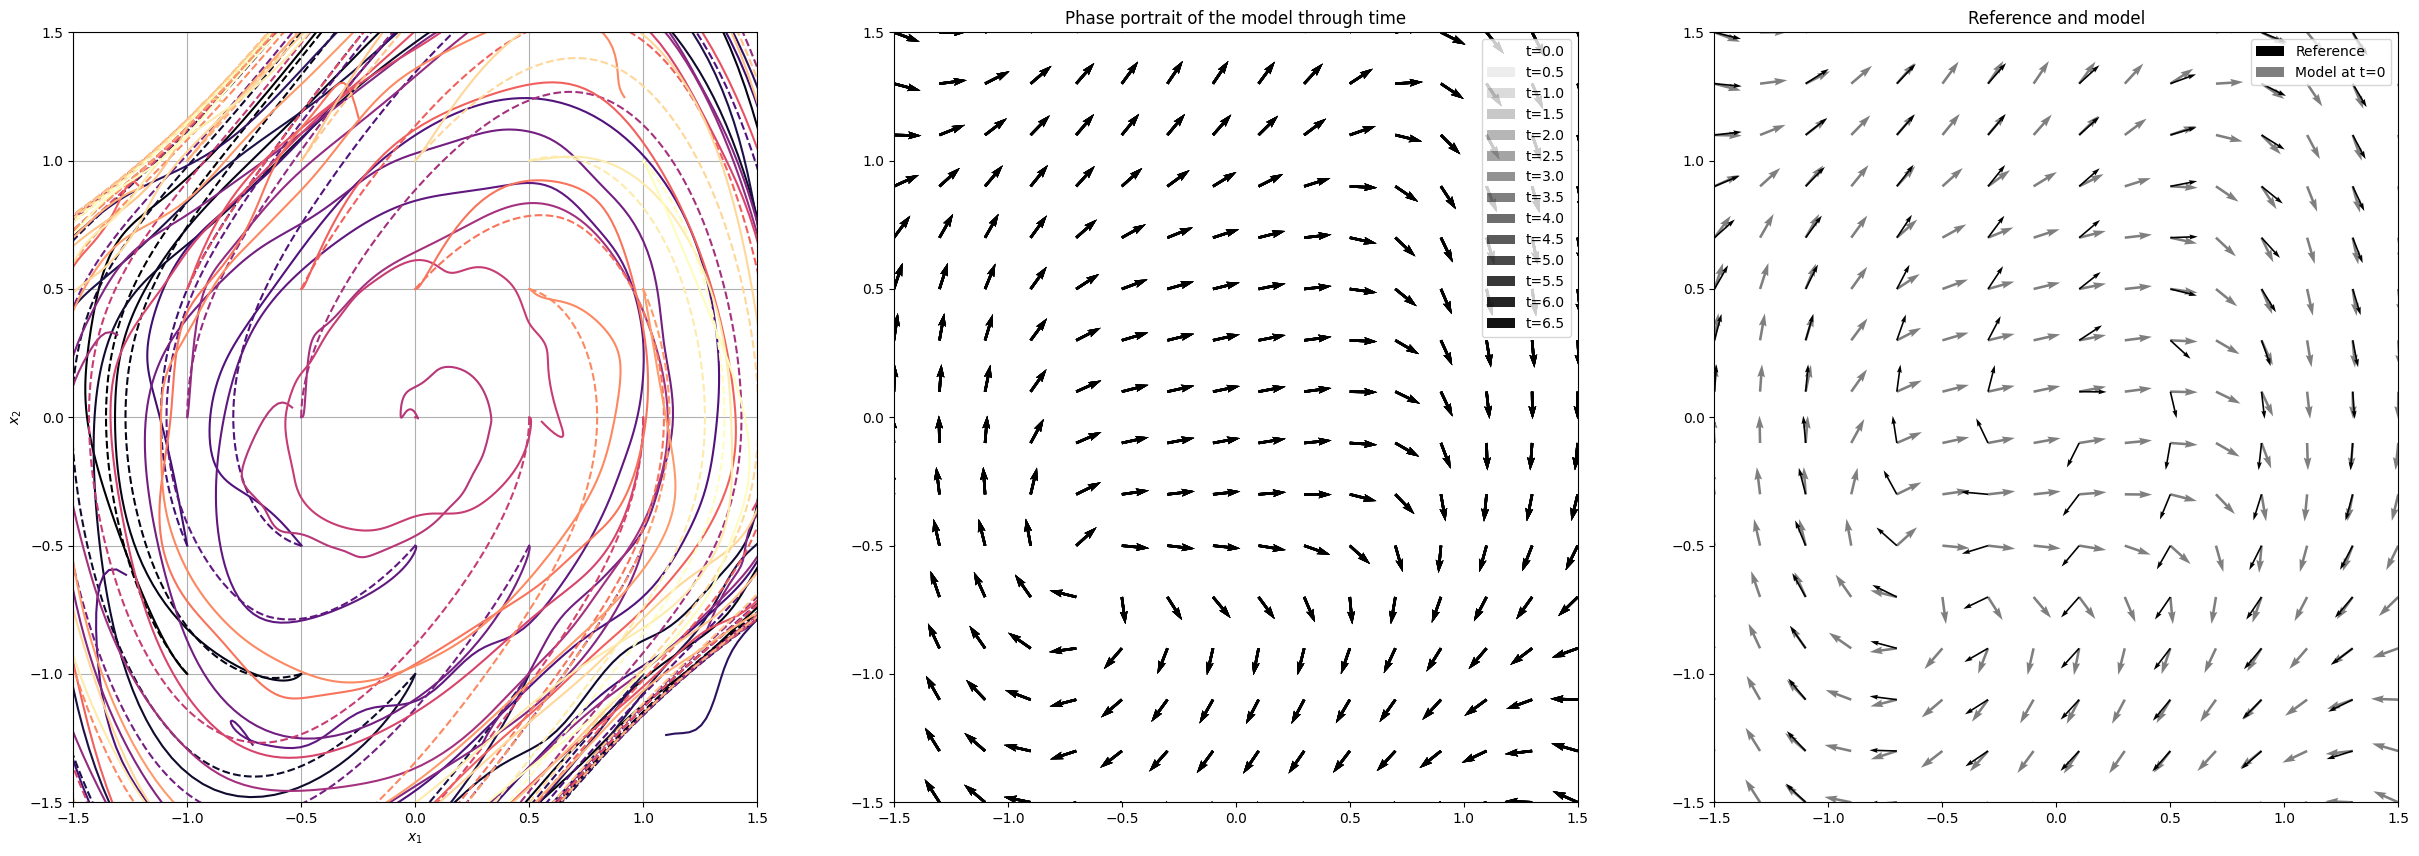

In [71]:
display_results(model_2)
plt.show()

In [72]:
def get_references():
    references = []
    np.random.seed(0)
    T_MAX_REFERENCE = 5.
    N_POINTS_REFERENCE = 1000
    c_is_reference = (np.random.random(size=(N_POINTS_REFERENCE, 2))-0.5) * 10
    for c_i in c_is_reference:
        t0 = np.random.random()*T_MAX_REFERENCE
        references.append(get_sol((t0, T_MAX_REFERENCE+t0), c_i))
    return torch.tensor(np.array(references), dtype=torch.float32)

def evaluate_model_on_trajectories(model, references):
    error = 0
    with torch.no_grad():
        for i in range(references.shape[0]):
            t = references[i, 0, :].unsqueeze(1)
            t0 = references[i, 0, 0:1] * torch.ones_like(t)
            x1_0 = references[i, 1, 0:1] * torch.ones_like(t)
            x2_0 = references[i, 2, 0:1] * torch.ones_like(t)
            y_hat = model(t, t0, x1_0, x2_0)
            y = references[i, 1:].T
            error += ((y_hat-y).abs()).mean()
    return error.item()/references.shape[0]

In [73]:
references = get_references()
print("Model 1")
print(evaluate_model_on_trajectories(model_1, references))
print("Model 2")
print(evaluate_model_on_trajectories(model_2, references))

Model 1
1.2956693115234375
Model 2
0.8086216430664063


In [74]:
def g_at_tau0(model, x1_0, x2_0):
    ones = torch.ones_like(x1_0)
    return model(ones, 0*ones, x1_0, x2_0).cpu()

from scipy.optimize import fsolve

def residual_np(xy, model, t0_scalar):
    x1_0 = torch.tensor([[xy[0]]], dtype=torch.float32)
    x2_0 = torch.tensor([[xy[1]]], dtype=torch.float32)
    with torch.no_grad():
        F = g_at_tau0(model, x1_0, x2_0)
    return F.squeeze(0).numpy()

def get_distance_with_true_fixed_point(model):
    root = fsolve(residual_np, x0=[0, 0], args=(model, 0.0))
    return (root[0]**2 + root[1]**2)**0.5

print(get_distance_with_true_fixed_point(model_1))
print(get_distance_with_true_fixed_point(model_2))

0.0267006055293024
0.012745767695423762


/var/folders/g7/l9_hhr256md6lt7yldvmnjjw0000gn/T/ipykernel_90889/1344574666.py:15: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  root = fsolve(residual_np, x0=[0, 0], args=(model, 0.0))


In [75]:
def poincare_residual(x1_0, model, t_guess):
    x1_0 = torch.tensor([[x1_0[0]]], dtype=torch.float32)
    x2_0 = torch.zeros_like(x1_0)
    
    ts = torch.linspace(0.05, t_guess*2, 400).reshape(-1,1)
    ones = torch.ones_like(ts)
    with torch.no_grad():
        traj = model(ts, 0*ones, x1_0.expand_as(ts), x2_0.expand_as(ts)).cpu().numpy()
    x1_t, x2_t = traj[:,0], traj[:,1]

    sign_changes = np.where(np.diff(np.sign(x2_t)))[0]
    if len(sign_changes) == 0:
        return np.array([1e3]), None
    i = sign_changes[0]
    
    t_cross = ts[i] + (ts[i+1]-ts[i]) * (-x2_t[i])/(x2_t[i+1]-x2_t[i])
    x1_cross = x1_t[i] + (x1_t[i+1]-x1_t[i]) * (-x2_t[i])/(x2_t[i+1]-x2_t[i])

    return np.array([x1_cross - x1_0.item()]), t_cross

def find_cycle_poincare(model, x1_guess, t_guess):
    sol = fsolve(lambda x: poincare_residual(x, model, t_guess)[0], x0=[x1_guess])
    _, T = poincare_residual(sol, model, t_guess)
    return sol[0], T

In [76]:
correct_T = (2*np.pi)/(1-(mu**2)/16+(17*mu**4)/3072)
correct_T

6.662735679549772

In [77]:
print(find_cycle_poincare(model_1, 1., correct_T))
print(find_cycle_poincare(model_2, 1., correct_T))

(np.float64(0.0653486517309754), tensor([3.2291], device='mps:0'))
(np.float64(0.4431803584235719), tensor([0.0501], device='mps:0'))


/var/folders/g7/l9_hhr256md6lt7yldvmnjjw0000gn/T/ipykernel_90889/1808715715.py:22: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  sol = fsolve(lambda x: poincare_residual(x, model, t_guess)[0], x0=[x1_guess])
